# CRPS Random Forest — Rust backend
Train a CRPS Random Forest on a synthetic dataset with 50 000 samples and 400 features
using the Rust-accelerated `distreebu_rs` backend.

## Configuration

In [1]:
CFG = dict(
    n_samples    = 50_000,   # training set size
    n_features   = 400,      # number of features
    n_test       = 2_000,    # test set size
    n_trees      = 10,      # trees in the forest
    max_depth    = 6,        # max tree depth
    min_ss       = 20,       # min_samples_split
    bag_fraction = 0.6,      # fraction of data per tree (no replacement)
    n_jobs       = 1,        # parallel workers (>1 requires joblib)
    seed         = 42,
)

## Imports

In [2]:
import time
import numpy as np
import distreebu_rs as rs

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

if CFG['n_jobs'] > 1:
    from joblib import Parallel, delayed

print(f"distreebu_rs loaded — available: {[s for s in dir(rs) if not s.startswith('_')]}")

distreebu_rs loaded — available: ['FenwickTree', 'MinMaxHeap', 'RegressionTreeCRPS', 'RegressionTreeQuadratic', 'RegressionTreeQuantile', 'distreebu_rs', 'entropies_crps', 'entropies_multi_quantiles', 'entropies_quadratic']


## Synthetic data

Heteroscedastic benchmark: only the first 4 features are informative; the remaining 396 are pure noise.

$$y = \sin(2\pi x_0) + x_1 \cos(\pi x_2) + 0.3\,(1 + |x_3|)\,\varepsilon, \quad \varepsilon \sim \mathcal{N}(0,1)$$

In [3]:
def make_data(n, p, n_test, seed):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n + n_test, p)).astype(np.float64)
    noise_scale = 0.3 * (1.0 + np.abs(X[:, 3]))
    y = (
        np.sin(2 * np.pi * X[:, 0])
        + X[:, 1] * np.cos(np.pi * X[:, 2])
        + noise_scale * rng.standard_normal(n + n_test)
    )
    return X[:n], y[:n], X[n:], y[n:]


t0 = time.perf_counter()
X_train, y_train, X_test, y_test = make_data(
    CFG['n_samples'], CFG['n_features'], CFG['n_test'], CFG['seed']
)
print(f"Data generated in {time.perf_counter()-t0:.2f}s")
print(f"X_train: {X_train.shape}   y_train mean={y_train.mean():.3f} std={y_train.std():.3f}")
print(f"X_test:  {X_test.shape}")
print(f"Memory (X_train float64): {X_train.nbytes/1e6:.0f} MB")

Data generated in 0.68s
X_train: (50000, 400)   y_train mean=-0.007 std=1.153
X_test:  (2000, 400)
Memory (X_train float64): 160 MB


## Train the forest

In [4]:
def fit_one_tree(tree_id, X_train, y_train, cfg):
    """Bootstrap-sample, fit one CRPS tree, return (tree, idx_train, idx_oob)."""
    rng   = np.random.default_rng(cfg['seed'] + tree_id)
    n     = X_train.shape[0]
    n_bag = int(cfg['bag_fraction'] * n)
    perm  = rng.permutation(n)
    idx_train, idx_oob = perm[:n_bag], perm[n_bag:]

    tree = rs.RegressionTreeCRPS(
        max_depth        = cfg['max_depth'],
        min_samples_split= cfg['min_ss'],
    )
    tree.fit(X_train[idx_train].tolist(), y_train[idx_train].tolist())
    return tree, idx_train, idx_oob


# OOB tracking: sample index → list of tree IDs where it was out-of-bag
sample2oob = {i: [] for i in range(CFG['n_samples'])}
trees       = [None] * CFG['n_trees']
results     = [None] * CFG['n_trees']

t_train = time.perf_counter()

if CFG['n_jobs'] > 1:
    print(f"Parallel fitting with {CFG['n_jobs']} workers…")
    results = Parallel(n_jobs=CFG['n_jobs'], backend='loky')(
        delayed(fit_one_tree)(tid, X_train, y_train, CFG)
        for tid in range(CFG['n_trees'])
    )
else:
    for tid in tqdm(range(CFG['n_trees']), desc='Fitting trees'):
        results[tid] = fit_one_tree(tid, X_train, y_train, CFG)

for tid, (tree, idx_train, idx_oob) in enumerate(results):
    trees[tid] = tree
    for i in idx_oob:
        sample2oob[i].append(tid)

t_train_total = time.perf_counter() - t_train
print(f"\nTraining complete")
print(f"  Total time     : {t_train_total:.1f} s")
print(f"  Per tree (avg) : {t_train_total / CFG['n_trees'] * 1000:.0f} ms")

oob_sizes = [len(v) for v in sample2oob.values()]
print(f"  OOB trees/sample: mean={np.mean(oob_sizes):.1f}  "
      f"samples with ≥1 OOB tree: {sum(s>0 for s in oob_sizes):,}")

Fitting trees:   0%|          | 0/10 [00:00<?, ?it/s]


Training complete
  Total time     : 55.7 s
  Per tree (avg) : 5574 ms
  OOB trees/sample: mean=4.0  samples with ≥1 OOB tree: 49,717


## Forest structure — leaf statistics

In [10]:
leaf_sizes_all = []
for tid, tree in enumerate(trees):
    _, idx_train, _ = results[tid]
    probe = idx_train[:min(1000, len(idx_train))]
    leaves = tree.get_values_leaf(X_train[probe].tolist(), list(range(len(probe))))
    for _, yvals in leaves:
        leaf_sizes_all.append(len(yvals))

leaf_sizes_all = np.array(leaf_sizes_all)
print(f"Leaf sizes across all trees (probe of 1000 samples/tree):")
print(f"  mean   = {leaf_sizes_all.mean():.1f}")
print(f"  median = {np.median(leaf_sizes_all):.0f}")
print(f"  min    = {leaf_sizes_all.min()}")
print(f"  max    = {leaf_sizes_all.max()}")

Leaf sizes across all trees (probe of 1000 samples/tree):
  mean   = 522.3
  median = 300
  min    = 20
  max    = 3606


## Prediction — distributional bagging (vr-avg)

For each test point, pool leaf y-values from all trees (equal per-tree weight)
and read off the desired quantiles from the empirical CDF.

In [5]:
from tqdm import tqdm
def forest_predict_quantiles(trees, X_test, quantiles):
    """
    Returns array of shape (n_test, len(quantiles)).
    Each test point's predictive distribution is the mixture of leaf
    empirical distributions across all trees (equal per-tree weight).
    """
    n_test = X_test.shape[0]
    test_idxs = list(range(n_test))
    pools   = [[] for _ in range(n_test)]   # pooled y-values
    weights = [[] for _ in range(n_test)]   # per-value weights

    for tree in trees:
        leaves = tree.get_values_leaf(X_test.tolist(), test_idxs)
        for leaf_idxs, leaf_yvals in leaves:
            w = 1.0 / len(leaf_yvals)       # uniform within-leaf
            for i in leaf_idxs:
                pools[i].extend(leaf_yvals)
                weights[i].extend([w] * len(leaf_yvals))

    out = np.empty((n_test, len(quantiles)))
    for i in tqdm(range(n_test)):
        vals = np.asarray(pools[i])
        wts  = np.asarray(weights[i])
        wts /= wts.sum()
        order       = np.argsort(vals)
        vals_sorted = vals[order]
        cdf         = np.cumsum(wts[order])
        for j, q in enumerate(quantiles):
            idx      = np.searchsorted(cdf, q)
            out[i,j] = vals_sorted[min(idx, len(vals_sorted)-1)]
    return out


QUANTILES     = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
N_TEST_EVAL   = min(500, CFG['n_test'])

print(f"Predicting quantiles {QUANTILES} on {N_TEST_EVAL} test points…")
t0 = time.perf_counter()
pred_q = forest_predict_quantiles(trees, X_test[:N_TEST_EVAL], QUANTILES)
t_pred = time.perf_counter() - t0
print(f"Done in {t_pred:.2f}s  ({N_TEST_EVAL/t_pred:.0f} samples/s)")
print(f"pred_q shape: {pred_q.shape}")

Predicting quantiles [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95] on 500 test points…


100% 500/500 [00:01<00:00, 471.22it/s]

Done in 1.35s  (369 samples/s)
pred_q shape: (500, 7)


## Quality metrics

In [6]:
y_eval = y_test[:N_TEST_EVAL]

print("Prediction intervals:")
for (lo_q, hi_q), nominal in [((0.10, 0.90), 0.80), ((0.05, 0.95), 0.90)]:
    lo = pred_q[:, QUANTILES.index(lo_q)]
    hi = pred_q[:, QUANTILES.index(hi_q)]
    coverage = np.mean((y_eval >= lo) & (y_eval <= hi))
    width    = np.mean(hi - lo)
    print(f"  {int(nominal*100)}% PI  coverage={coverage:.3f} (nominal {nominal})  "
          f"avg width={width:.3f}")

med_idx = QUANTILES.index(0.50)
mae = np.mean(np.abs(pred_q[:, med_idx] - y_eval))
print(f"\nMedian absolute error (q=0.5): {mae:.4f}")

Prediction intervals:
  80% PI  coverage=0.830 (nominal 0.8)  avg width=2.266
  90% PI  coverage=0.920 (nominal 0.9)  avg width=2.964

Median absolute error (q=0.5): 0.6808


## Empirical CRPS

Energy-score form:  $\text{CRPS}(F, y) = \mathbb{E}|X - y| - \tfrac{1}{2}\mathbb{E}|X - X'|$

In [7]:
def empirical_crps(trees, X_test, y_test, max_pool=500, max_pairs=2000, seed=0):
    n_test    = X_test.shape[0]
    test_idxs = list(range(n_test))
    pools     = [[] for _ in range(n_test)]

    for tree in trees:
        leaves = tree.get_values_leaf(X_test.tolist(), test_idxs)
        for leaf_idxs, leaf_yvals in leaves:
            for i in leaf_idxs:
                pools[i].extend(leaf_yvals)

    rng  = np.random.default_rng(seed)
    vals = np.empty(n_test)
    for i in range(n_test):
        pool = np.asarray(pools[i])
        if len(pool) > max_pool:
            pool = rng.choice(pool, max_pool, replace=False)
        term1 = np.mean(np.abs(pool - y_test[i]))
        m = len(pool)
        if m > 200:
            a = rng.integers(0, m, max_pairs)
            b = rng.integers(0, m, max_pairs)
            term2 = 0.5 * np.mean(np.abs(pool[a] - pool[b]))
        else:
            term2 = 0.5 * np.abs(pool[:,None] - pool[None,:]).mean()
        vals[i] = term1 - term2
    return vals


N_CRPS = min(200, N_TEST_EVAL)
print(f"Computing empirical CRPS on {N_CRPS} test points…")
t0 = time.perf_counter()
crps_vals = empirical_crps(trees, X_test[:N_CRPS], y_test[:N_CRPS])
print(f"Done in {time.perf_counter()-t0:.2f}s")
print(f"Mean CRPS : {crps_vals.mean():.4f}")
print(f"Std  CRPS : {crps_vals.std():.4f}")

Computing empirical CRPS on 200 test points…
Done in 0.29s
Mean CRPS : 0.4905
Std  CRPS : 0.4045


## Visualisation

NameError: name 'leaf_sizes_all' is not defined

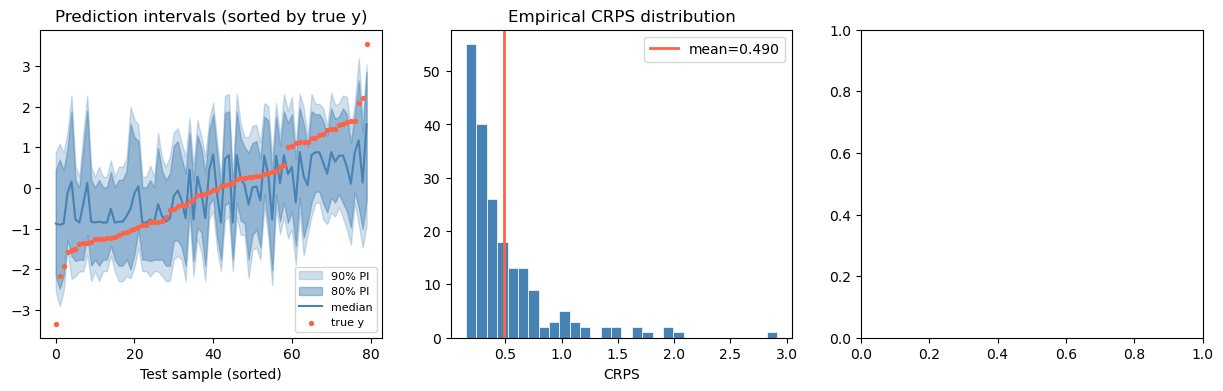

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Panel 1: prediction intervals on 80 test points ───────────────────────────
ax = axes[0]
N_PLOT = 80
order  = np.argsort(y_eval[:N_PLOT])
x_axis = np.arange(N_PLOT)

lo80 = pred_q[:N_PLOT, QUANTILES.index(0.10)][order]
hi80 = pred_q[:N_PLOT, QUANTILES.index(0.90)][order]
lo90 = pred_q[:N_PLOT, QUANTILES.index(0.05)][order]
hi90 = pred_q[:N_PLOT, QUANTILES.index(0.95)][order]
med  = pred_q[:N_PLOT, QUANTILES.index(0.50)][order]
ytrue= y_eval[:N_PLOT][order]

ax.fill_between(x_axis, lo90, hi90, alpha=0.25, color='steelblue', label='90% PI')
ax.fill_between(x_axis, lo80, hi80, alpha=0.45, color='steelblue', label='80% PI')
ax.plot(x_axis, med,   color='steelblue', lw=1.5, label='median')
ax.scatter(x_axis, ytrue, s=8, color='tomato', zorder=3, label='true y')
ax.set_title('Prediction intervals (sorted by true y)')
ax.set_xlabel('Test sample (sorted)')
ax.legend(fontsize=8)

# ── Panel 2: CRPS distribution ────────────────────────────────────────────────
ax = axes[1]
ax.hist(crps_vals, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(crps_vals.mean(), color='tomato', lw=2, label=f'mean={crps_vals.mean():.3f}')
ax.set_title('Empirical CRPS distribution')
ax.set_xlabel('CRPS')
ax.legend()

# ── Panel 3: leaf size distribution ──────────────────────────────────────────
ax = axes[2]
ax.hist(leaf_sizes_all, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(np.median(leaf_sizes_all), color='tomato', lw=2,
           label=f'median={np.median(leaf_sizes_all):.0f}')
ax.set_title('Leaf size distribution')
ax.set_xlabel('Samples per leaf')
ax.legend()

plt.tight_layout()
plt.show()

## Summary

In [17]:
print("=" * 50)
print("CRPS Random Forest — training summary")
print("=" * 50)
print(f"  n_samples (train)  : {CFG['n_samples']:,}")
print(f"  n_features         : {CFG['n_features']:,}")
print(f"  n_trees            : {CFG['n_trees']}")
print(f"  max_depth          : {CFG['max_depth']}")
print(f"  Training time      : {t_train_total:.1f} s")
print(f"  Per-tree time      : {t_train_total/CFG['n_trees']*1000:.0f} ms")
print(f"  Mean CRPS          : {crps_vals.mean():.4f}")
print("=" * 50)
print()
print("Objects available for further use:")
print("  trees       — list of fitted RegressionTreeCRPS objects")
print("  sample2oob  — dict[sample_idx -> list of OOB tree IDs]")
print("  pred_q      — array (n_test, n_quantiles) of quantile predictions")
print("  crps_vals   — array of per-sample CRPS values")

CRPS Random Forest — training summary
  n_samples (train)  : 50,000
  n_features         : 400
  n_trees            : 100
  max_depth          : 6
  Training time      : 554.9 s
  Per-tree time      : 5549 ms
  Mean CRPS          : 0.6407

Objects available for further use:
  trees       — list of fitted RegressionTreeCRPS objects
  sample2oob  — dict[sample_idx -> list of OOB tree IDs]
  pred_q      — array (n_test, n_quantiles) of quantile predictions
  crps_vals   — array of per-sample CRPS values
